In [1]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
## This code block is ~2 (1.5 ish) GB of memory on its own. 

fires = pd.read_parquet("s3://maap-ops-workspace/shared/zbecker/TESS_fire_spread/sigdeltas_Tess.parq")
subset_fires = gpd.read_parquet("s3://maap-ops-workspace/shared/zbecker/YANG/large_feds_faf_double_matched.parq")
subset_fires = subset_fires.to_crs(4326)

subset_fires["centroid"] = subset_fires.to_crs(4326).centroid
fires["UfireID"] = fires.mergeid.astype("int").astype("str") + "_" + fires.year.astype("str")
subset_fires["UfireID"] = subset_fires.mergeid.astype("str") + "_" + subset_fires.year.astype("str")
subset_fires["polygon"] = subset_fires.geometry
fires = fires[fires.UfireID.isin(subset_fires[subset_fires.intersectsMTBS == True].UfireID)]
fname = pd.read_csv("s3://maap-ops-workspace/shared/zbecker/Eli_MTBS_vs_FEDS/v6_output.csv")

fires = fires.merge(subset_fires[['UfireID', 'centroid', 'polygon']], on = 'UfireID' )
fires = gpd.GeoDataFrame(fires, geometry = 'polygon')

def get_st_sp_fire(df, days_after = 7):
    df.loc[:, "start_time"] = df.t.min()
    df.loc[:, "end_time"] = df.t.max()
    df.loc[:, "end_time_plus"] = df.t.astype("datetime64[ns]").max()  + datetime.timedelta(days = days_after)
    df = df.loc[df.t == df.t.max(), :]
    return(df)
    
fires_sm = fires.groupby("UfireID").apply(get_st_sp_fire).reset_index(drop = True)
fires_sm["stable_index"] = fires_sm.index

In [3]:
## Reading in my giant geoparquet

precip = gpd.read_parquet(os.path.abspath("IMERG/daily_climatology/daily_climatology")) # Not yet finished, but lets have some fun with it. 

In [4]:
precip = precip.drop(columns=["t", "name"])
precip = precip.rename(columns={"time": "t"})

In [5]:
# Oh shit, did all my extraction assuming local was the same at UTC. Lets see how much damage that caused. 

# def correct_utc_day(df):
#     lat = df.centroid.x.values

#     UTC = LMST - (Longitude / 15)

print(f" Maximum deviation from UTC is UTC - {precip.centroid.x.min()/15} and UTC - {precip.centroid.x.max()/15}, which is {12 - precip.centroid.x.min()/15} and {12 - precip.centroid.x.max()/15}, which wouldn't change the day itself ")
print(f"UTC devides up the west coast closter to 12:00:00 - 12:00:00 (16:00:00 - 16:00:00 is ~ 4 horus off")
print(f"UTC devides up the east coast closter to 00:00:00 (19:00:00 - 19:00:00) or five hours from midnight and 7 hours from 12")
print("Does this change the number of granuals returned? That would make a difference")


auth = earthaccess.login()


results = earthaccess.search_data(
    doi='10.5067/GPM/IMERGDF/DAY/07',
    temporal=("2019-03-13T12:00:00", "2019-03-14T00:00:00"),
)

fn = earthaccess.open(results)
len_with_midnight = len(fn)

results = earthaccess.search_data(
    doi='10.5067/GPM/IMERGDF/DAY/07',
    temporal=("2019-03-13T12:00:00", "2019-03-14T12:00:00"),
)

fn2 = earthaccess.open(results)
len_with_noon = len(fn2)

if (len_with_midnight == len_with_noon):
    print("IMERG graual retrival ignores hourly data for daily granual retrival. Everything is fine.")
if(len_with_midnight != len_with_noon):
    print("IMERG granual retival uses houly specifications. Redo retrival.")




## This casues 

 Maximum deviation from UTC is UTC - -8.262248634919235 and UTC - -4.961608946426586, which is 20.262248634919235 and 16.961608946426587, which wouldn't change the day itself 
UTC devides up the west coast closter to 12:00:00 - 12:00:00 (16:00:00 - 16:00:00 is ~ 4 horus off
UTC devides up the east coast closter to 00:00:00 (19:00:00 - 19:00:00) or five hours from midnight and 7 hours from 12
Does this change the number of granuals returned? That would make a difference


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

IMERG graual retrival ignores hourly data for daily granual retrival. Everything is fine.


In [6]:
## TO DO 



def lst_to_utc(df, time_vars = ["start_time", "end_time", "end_time_plus"]):
    for dt_var in time_vars:
        lon = df.centroid.x.values
        new_dt = df[dt_var].astype('datetime64[ns]') - datetime.timedelta(hours = (lon[0] / 15))
        df[f"{dt_var}_utc"] = new_dt
    return(df)

#precip = precip.groupby("UfireID").apply(lst_to_utc).reset_index(drop = True)
# def utc_to_lst(df):
#     minx, miny, maxx, maxy = df.polygon.bounds ## want  to match the lon used for IMERG extraction
def generate_timesteps(start, end, delta):
    """
    Returns a list of datetimes between `start` and `end` at `delta` increments.
    """
    timesteps = []
    current = start
    
    while current <= end:
        timesteps.append(current)
        current += delta
        
    return timesteps

def correct_growth_to_daily(df):
    # Correct growth to go from 00:00:00 - 00:00:00 values, to match daily precip
    # IMERG is in UTC not local. Oh no! gotta convert it. 
    # I think 12:00:00 - 12:00:00 better captures the west coast, and the east coast is unsatisfying no matter what. Going 12:00:00 - 12:00:00

    # think about what that means for first increment

    start_date = frs[frs.t == frs.t.min()].t.astype("datetime64[ns]")
    end_date = frs[frs.t == frs.t.max()].t.astype("datetime64[ns]")
    
    if(frs[frs.t == frs.t.min()].t.astype("datetime64[ns]").dt.hour.values[0] == 0):
        # Get the 12 hour day before
        start_date = frs[frs.t == frs.t.min()].t.astype("datetime64[ns]") - datetime.timedelta(hours = 12)
    if(frs[frs.t == frs.t.max()].t.astype("datetime64[ns]").dt.hour.values[0] == 0):
        end_date = frs[frs.t == frs.t.max()].t.astype("datetime64[ns]") + datetime.timedelta(hours = 12) # The noon value one slot later

    time_lists = generate_timesteps(start_date, end_date, delta =  datetime.timedelta(hours = 12))
    
        

    return(df)

# def correct_daily_time(df):
    
#     ## Either add a noon value to the daily growth or drop the hour column from the "t" in fires

In [7]:



#precipm = precip.merge(fires.loc[:, ["UfireID","t", "centroid"]],  on = ["UfireID"]) ## Shit I need daily growth increments. Need to merge on "t" as well.  

In [8]:
## A quick an dirty exploratory plot

precip["end_time_dt"] = precip.end_time.astype("datetime64[ns]").dt.strftime("%Y-%m-%d")
precip["end_time_plus_dt"] = precip.end_time_plus.astype("datetime64[ns]").dt.strftime("%Y-%m-%d")

def get_precip_diff(df, var_name = "precipitation"):
    df = df.sort_values(by = "t")
    df[f"{var_name}_diff"] = df[var_name].diff()
    df.loc[:, "after_end"] = False
    df.loc[df.t > df.end_time_dt, "after_end"] = True
    return(df)

    
precip = precip.groupby("UfireID").apply(get_precip_diff).reset_index(drop = True)


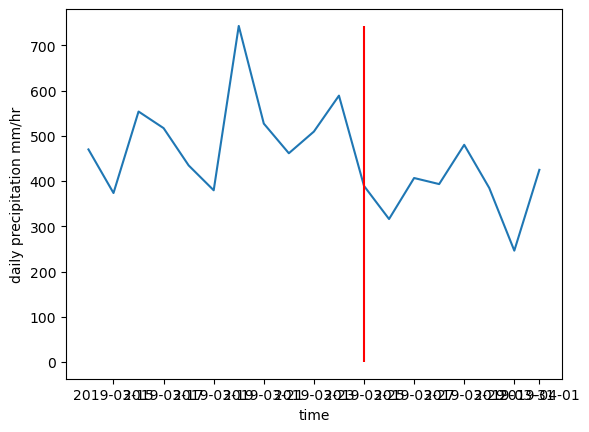

In [15]:
import matplotlib.pyplot as plt
foo = precip[precip.UfireID == "10210_2019"]
plt.plot(foo.t, foo.precipitation)
plt.ylabel("daily precipitation mm/hr")
plt.xlabel("time")
plt.vlines(x = foo.end_time_dt.astype("datetime64[ns]").max(), ymin = 0, ymax = foo.precipitation.max(), label= "End of fire", color = "red")

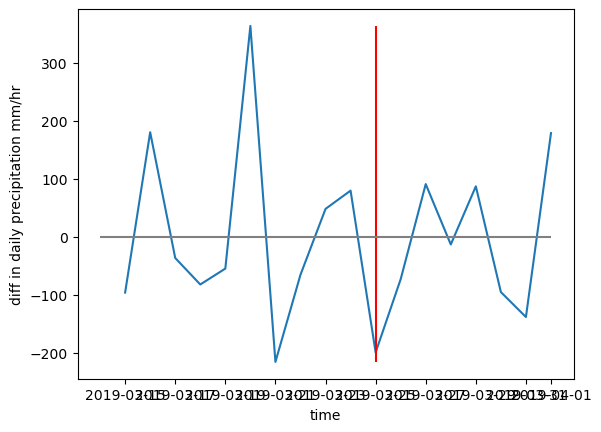

In [19]:
foo = precip[precip.UfireID == "10210_2019"]
plt.plot(foo.t, foo.precipitation_diff)
plt.ylabel("diff in daily precipitation mm/hr")
plt.xlabel("time")
plt.vlines(x = foo.end_time_dt.astype("datetime64[ns]").max(), ymin = foo.precipitation_diff.min(), ymax = foo.precipitation_diff.max(), label= "End of fire", color = "red")
plt.hlines(y = 0, xmin = foo.t.min(), xmax = foo.t.max(), label= "Zero", color = "grey")

In [25]:
def find_big_precip(df):
    max_diff = df.precipitation_diff.max()
    max_precip = df.precipitation.max()
    df["max_precip_in_end"] = False
    df["max_precip_diff_in_end"] = False

    if(any(df[df.precipitation_diff == max_diff].t >= df.end_time_dt.max())):
        df["max_precip_diff_in_end"] = True
    if(any(df[df.precipitation == max_precip].t >= df.end_time_dt.max())):
        df["max_precip_in_end"] = True
    return(df)
    

In [ ]:
precip = precip.groupby("UfireID").apply(find_big_precip).reset_index(drop = True)

In [44]:
# # def num_growth_increments(df):
# #     df.loc[:, "num_growth_increments"] = len(df.area_growth_at_t_km2.unique())
# #     return(df)
# precip = precip.groupby("UfireID").apply(num_growth_increments).reset_index(drop = True)


    

In [46]:
print(f"{(len(precip[precip.max_precip_in_end].UfireID.unique()) / len(precip.UfireID.unique()) ) * 100} percent of fires had thier largest precip event sometime 7 days after burning, not during.")


print(f"{(len(precip[precip.max_precip_diff_in_end].UfireID.unique()) / len(precip.UfireID.unique()) ) * 100} percent of fires had thier largest uptick in precip 7 days after burning, not during.")
print(f"This includes {len(precip[precip.num_growth_increments == 1].UfireID.unique())} fires that have only one growth increment, or {(len(precip[precip.num_growth_increments == 1].UfireID.unique())/len(precip.UfireID.unique())) * 100} percent of fires")



67.09859154929578 percent of fires had thier largest precip event sometime 7 days after burning, not during.
68.95774647887323 percent of fires had thier largest uptick in precip 7 days after burning, not during.
This includes 1775 fires that have only one growth increment, or 100.0 percent of fires


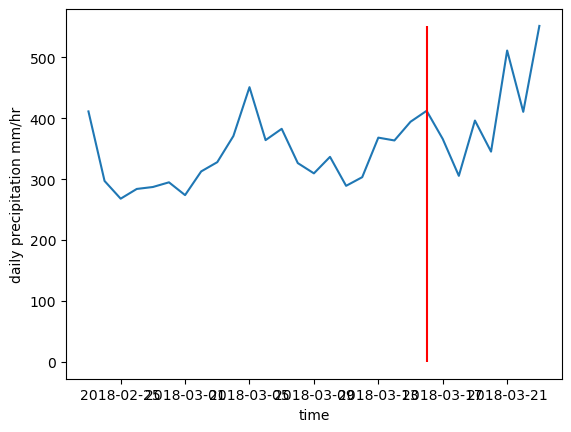

In [37]:
## Example with uptick

uptick_ids = precip[precip.max_precip_in_end].UfireID.unique()

tmp = precip[precip.UfireID == uptick_ids[10]]
plt.plot(tmp.t, tmp.precipitation)
plt.ylabel("daily precipitation mm/hr")
plt.xlabel("time")
plt.vlines(x = tmp.end_time_dt.astype("datetime64[ns]").max(), ymin = 0, ymax = tmp.precipitation.max(), label= "End of fire", color = "red")


10318_2014 is broken!
2014-02-26 12:00:00, to 2014-02-26 12:00:00


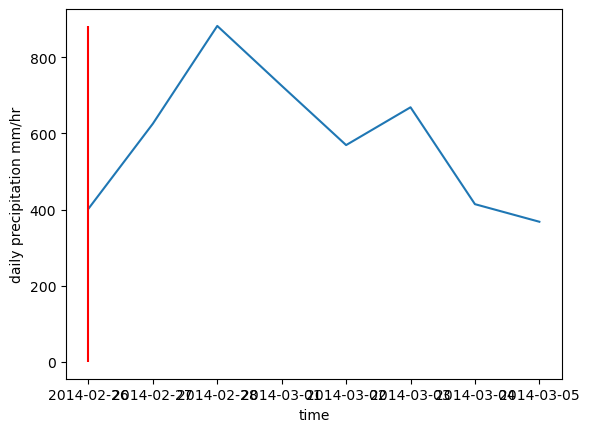

In [42]:
uptick_ids = precip[precip.max_precip_in_end].UfireID.unique()

tmp = precip[precip.UfireID == uptick_ids[4]]  ## What's up with 4??????
print(f"{uptick_ids[4]} is broken!")
print(f"{tmp.start_time.max()}, to {tmp.end_time.max()}")
plt.plot(tmp.t, tmp.precipitation)
plt.ylabel("daily precipitation mm/hr")
plt.xlabel("time")
plt.vlines(x = tmp.end_time_dt.astype("datetime64[ns]").max(), ymin = 0, ymax = tmp.precipitation.max(), label= "End of fire", color = "red")

10318_2014 is broken!
2022-03-02 12:00:00, to 2022-03-09 12:00:00


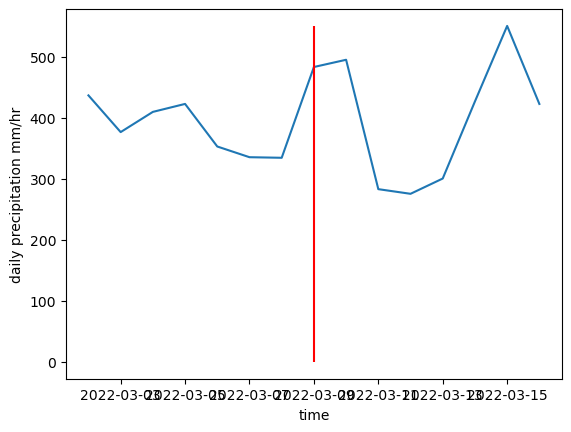

In [47]:
tmp = precip[precip.UfireID == uptick_ids[100]]  ## What's up with 4??????
print(f"{uptick_ids[4]} is broken!")
print(f"{tmp.start_time.max()}, to {tmp.end_time.max()}")
plt.plot(tmp.t, tmp.precipitation)
plt.ylabel("daily precipitation mm/hr")
plt.xlabel("time")
plt.vlines(x = tmp.end_time_dt.astype("datetime64[ns]").max(), ymin = 0, ymax = tmp.precipitation.max(), label= "End of fire", color = "red")

10318_2014 is broken!
2021-03-29 12:00:00, to 2021-03-29 12:00:00


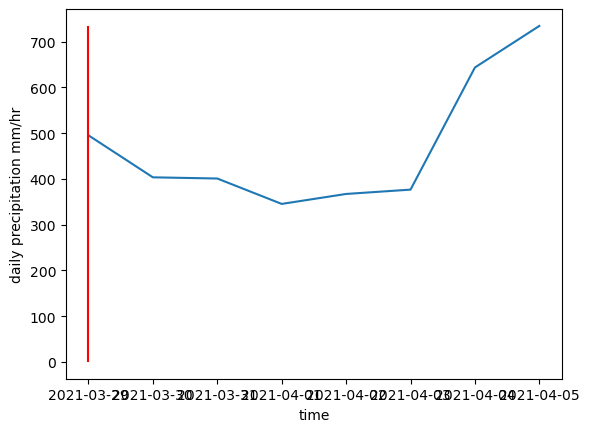

In [48]:
tmp = precip[precip.UfireID == uptick_ids[302]]  ## What's up with 4??????
print(f"{uptick_ids[4]} is broken!")
print(f"{tmp.start_time.max()}, to {tmp.end_time.max()}")
plt.plot(tmp.t, tmp.precipitation)
plt.ylabel("daily precipitation mm/hr")
plt.xlabel("time")
plt.vlines(x = tmp.end_time_dt.astype("datetime64[ns]").max(), ymin = 0, ymax = tmp.precipitation.max(), label= "End of fire", color = "red")

10318_2014 is broken!
2019-03-18 12:00:00, to 2019-03-18 12:00:00


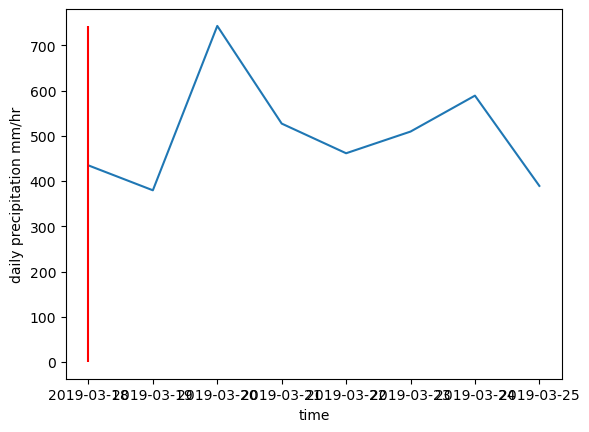

In [49]:
tmp = precip[precip.UfireID == uptick_ids[30]]  ## What's up with 4??????
print(f"{uptick_ids[4]} is broken!")
print(f"{tmp.start_time.max()}, to {tmp.end_time.max()}")
plt.plot(tmp.t, tmp.precipitation)
plt.ylabel("daily precipitation mm/hr")
plt.xlabel("time")
plt.vlines(x = tmp.end_time_dt.astype("datetime64[ns]").max(), ymin = 0, ymax = tmp.precipitation.max(), label= "End of fire", color = "red")

10318_2014 is broken!
2013-04-09 12:00:00, to 2013-04-10 12:00:00


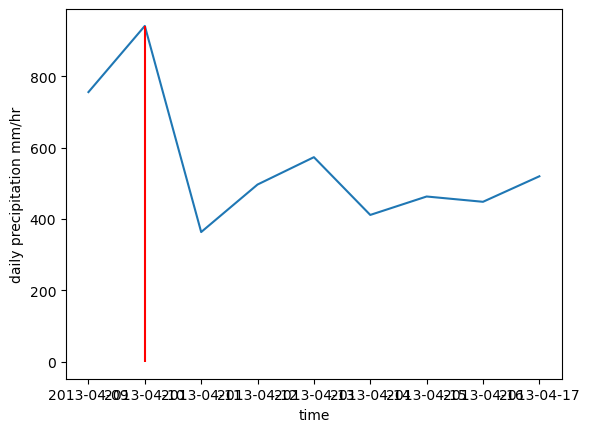

In [50]:
tmp = precip[precip.UfireID == uptick_ids[321]]  ## What's up with 4??????
print(f"{uptick_ids[4]} is broken!")
print(f"{tmp.start_time.max()}, to {tmp.end_time.max()}")
plt.plot(tmp.t, tmp.precipitation)
plt.ylabel("daily precipitation mm/hr")
plt.xlabel("time")
plt.vlines(x = tmp.end_time_dt.astype("datetime64[ns]").max(), ymin = 0, ymax = tmp.precipitation.max(), label= "End of fire", color = "red")